In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

In [186]:
def pareto_frontier_3D(points, maximize=(False, False, False)):
    """Return the nondominated points for exactly three objectives.

    Objectives are minimized by default. Set an entry in ``maximize`` to True
    for any objective that should be maximized instead.
    """
    points = np.asarray(points)
    if points.ndim != 2 or points.shape[1] != 3:
        raise ValueError("points must have shape (n_points, 3)")

    maximize = np.asarray(maximize, dtype=bool)
    if maximize.shape != (3,):
        raise ValueError("maximize must contain one boolean per objective")

    oriented_points = np.where(maximize, -points, points)
    is_dominated = np.zeros(len(points), dtype=bool)

    for index, candidate in enumerate(oriented_points):
        no_worse = np.all(oriented_points <= candidate, axis=1)
        strictly_better = np.any(oriented_points < candidate, axis=1)
        is_dominated[index] = np.any(no_worse & strictly_better)

    return points[~is_dominated]

def pareto_frontier_2D(points):
    """
    points: array-like of shape (n_points, 2)
            Minimization on both dimensions
    returns: Pareto-optimal points
    """
    points = np.asarray(points)

    # Sort by first objective (x), ascending
    sorted_idx = np.argsort(points[:, 0])
    points = points[sorted_idx]

    pareto = []
    best_y = np.inf

    for x, y, z in points:
        if y < best_y:
            pareto.append([x, y, z])
            best_y = y

    return np.array(pareto)

def clip(x, lower = 0, upper = 1.0):
    return max(lower, min(x, upper))


def clip(x, lower=0, upper=1.0):
    return max(lower, min(x, upper))

In [216]:
# miliseconds
MEAN_LATENCY = 500 # average model latency in milliseconds
LATENCY_VAR = MEAN_LATENCY*0.20 # miliseconds
INFERENCE_LATENCY_VAR = MEAN_LATENCY*0.01 # miliseconds   

# joules
MEAN_ENERGY = 1000 # average model energy inference cost in joules
ENERGY_VAR = MEAN_ENERGY*0.20 # joules
INFERENCE_ENERGY_VAR = MEAN_ENERGY*0.01 # joules


In [217]:
print("MEAN_ENERGY:", MEAN_ENERGY, "J")
print("ENERGY_VAR:", ENERGY_VAR, "J")
print("INFERENCE_ENERGY_VAR:", INFERENCE_ENERGY_VAR, "J")
print()
print("MEAN_LATENCY:", MEAN_LATENCY, "ms")
print("LATENCY_VAR:", LATENCY_VAR, "ms")
print("INFERENCE_LATENCY_VAR:", INFERENCE_LATENCY_VAR, "ms")



MEAN_ENERGY: 1000 J
ENERGY_VAR: 200.0 J
INFERENCE_ENERGY_VAR: 10.0 J

MEAN_LATENCY: 500 ms
LATENCY_VAR: 100.0 ms
INFERENCE_LATENCY_VAR: 5.0 ms


In [218]:
class Model:
    def __init__(self, name, error_rate, energy_cost, latency):
        self.name = name
        self.error_rate = error_rate
        self.accuracy = 1 - error_rate
        self.energy_cost = energy_cost
        self.latency = latency

    def inference(self, task_difficulty):        
        hit = self.accuracy >= task_difficulty
        energy_inference_cost = self.energy_cost + np.random.normal(loc=0, scale=INFERENCE_ENERGY_VAR)
        latency = self.latency + np.random.normal(loc=0, scale=INFERENCE_LATENCY_VAR)
        return hit, energy_inference_cost, latency  
    
class Task:
    def __init__(self, difficulty):
        self.difficulty = difficulty 





In [223]:
# generate set of solutions
n_solutions = 25
solutions = []
models = []
for i in range(n_solutions):
    name = 'm'+str(i)
    error_rate = clip(np.random.normal(loc=0.5, scale=0.15),0,1)
    size = 1-error_rate
    mean_energy_cost = size*MEAN_ENERGY + np.random.normal(loc=0, scale=ENERGY_VAR)
    time_cost = size*MEAN_LATENCY + np.random.normal(loc=0, scale=INFERENCE_LATENCY_VAR)
    #time_cost = clip(time_cost,0.1,10)
    #model = Model(name,error_rate,mean_energy_cost, time_cost)
    solutions.append((error_rate,mean_energy_cost,time_cost))
solutions = np.array(solutions)

    


In [224]:
pareto = pareto_frontier_2D(solutions)

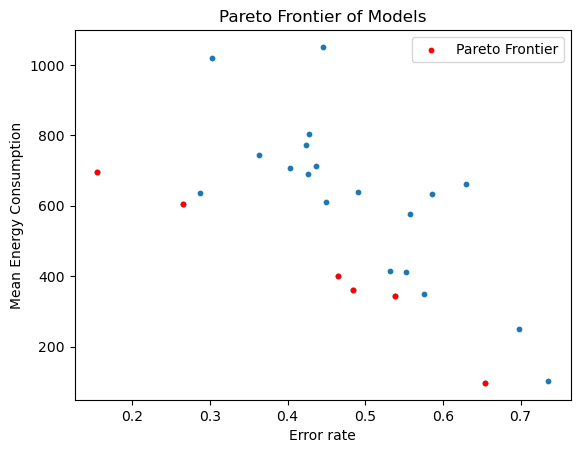

In [225]:
plt.scatter(solutions[:,0],solutions[:,1], s = 10)
plt.scatter(pareto[:,0],pareto[:,1],color='red', label='Pareto Frontier', s=10)
plt.title("Pareto Frontier of Models")
plt.xlabel("Error rate")
plt.ylabel("Mean Energy Consumption")
plt.legend()
plt.show()

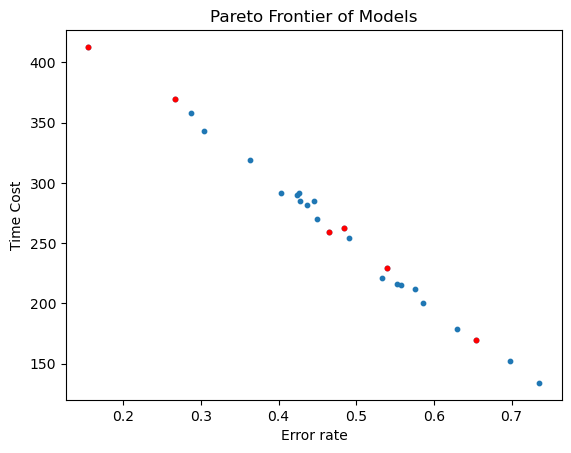

In [226]:
plt.scatter(solutions[:,0],solutions[:,2], s = 10)
plt.scatter(pareto[:,0],pareto[:,2],color='red', label='Pareto Frontier', s=10)
plt.title("Pareto Frontier of Models")
plt.xlabel("Error rate")
plt.ylabel("Time Cost")
plt.show()

In [227]:
pareto_models = []
models = []
for error_rate, mean_energy_cost, time_cost in pareto:
    model = Model(name,error_rate,mean_energy_cost,time_cost)
    pareto_models.append(model)

for error_rate, mean_energy_cost, time_cost in solutions:
    model = Model(name,error_rate,mean_energy_cost,time_cost)
    models.append(model)
    

In [270]:
n_pareto_models = len(pareto_models)
better_accuracy_model = pareto_models[0]
better_efficiency_model = pareto_models[-1]
better_tradeoff_model = pareto_models[int(n_pareto_models*0.5)]

print('\nBetter accuracy model')
print(f'Accuracy: {better_accuracy_model.accuracy:.3f}, Energy Cost: {better_accuracy_model.energy_cost:.0f}, Latency: {better_accuracy_model.latency:.0f}')

print('\nBetter tradeoff model')
print(f'Accuracy: {better_tradeoff_model.accuracy:.3f}, Energy Cost: {better_tradeoff_model.energy_cost:.0f}, Latency: {better_tradeoff_model.latency:.0f}')

print('\nBetter efficiency model')
print(f'Accuracy: {better_efficiency_model.accuracy:.3f}, Energy Cost: {better_efficiency_model.energy_cost:.0f}, Latency: {better_efficiency_model.latency:.0f}')


Better accuracy model
Accuracy: 0.845, Energy Cost: 697, Latency: 413

Better tradeoff model
Accuracy: 0.516, Energy Cost: 362, Latency: 262

Better efficiency model
Accuracy: 0.345, Energy Cost: 97, Latency: 170


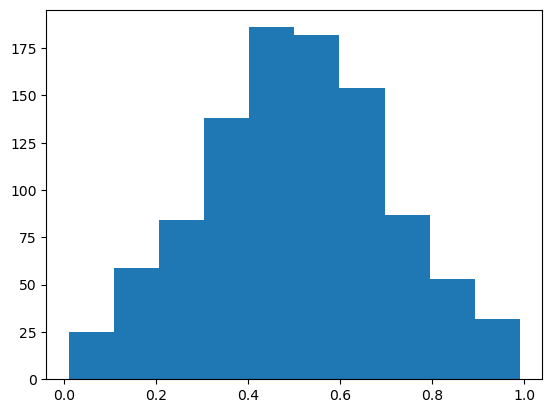

In [271]:
tasks = []
for t in range(1000):
    difficulty = np.random.normal(loc=0.5, scale=0.2)
    difficulty = clip(difficulty,0.01,0.99)
    #difficulty = 1.0
    #task = Task(difficulty)
    tasks.append(difficulty)
plt.hist(tasks)
plt.show()


In [272]:
task = tasks[0]
print(f"Task difficulty: {task:.2f}\n")
hit, energy, time = better_accuracy_model.inference(task)
print(f"Better accuracy model\n  Hit: {hit}, Energy: {energy:.0f}J, Time: {time:0.0f}ms")

hit, energy, time = better_tradeoff_model.inference(task)
print(f"Better tradeoff model\n  Hit: {hit}, Energy: {energy:.0f}J, Time: {time:0.0f}ms")

hit, energy, time = better_efficiency_model.inference(task)
print(f"Better efficiency model\n  Hit: {hit}, Energy: {energy:.0f}J, Time: {time:0.0f}ms")

Task difficulty: 0.39

Better accuracy model
  Hit: True, Energy: 694J, Time: 413ms
Better tradeoff model
  Hit: True, Energy: 361J, Time: 272ms
Better efficiency model
  Hit: False, Energy: 117J, Time: 176ms


In [338]:
BATTERY_JOULES = 18*10e3 # 18kJ

def simulate_inference(model, task):
    hit, energy, time = model.inference(task)    
    return hit, energy, time

def simulate_single_model(model, tasks, battery_capacity = BATTERY_JOULES):
    hits = []
    energies = []
    times = []
    early_dead = False
    for task in tasks:
        hit, energy, time = simulate_inference(model, task)
        hits.append(hit)
        energies.append(energy)
        times.append(time)
        battery_capacity -= energy
        if battery_capacity <= 0:
            early_dead = True
            break
    hit_rate = sum(hits)/len(hits)
    total_energy = sum(energies)
    total_time = sum(times)/(1000*60)
    joules_per_correct_task = total_energy/sum(hits) if sum(hits) > 0 else float('inf')

    return hit_rate, len(hits), sum(hits), total_energy, total_time, early_dead, joules_per_correct_task

def run_multiple_simulations(tasks, model, battery_capacity):
    results = []
    for i in range(1000):
        hit_rate, tasks_done, hits, total_energy, total_time, early_dead, joules_per_correct_task = simulate_single_model(model, tasks, battery_capacity)
        results.append([hit_rate, tasks_done, hits, total_energy, total_time, early_dead, joules_per_correct_task])
    return results 

def print_results(results, method_name):
    hit_rate = results[0]
    tasks_done = results[1]
    hits = results[2]
    total_energy = results[3]
    total_time = results[4]
    early_dead = results[5]
    joules_per_correct_task = results[6]

    print(f"{method_name}:")
    print(f"Hit rate: {hit_rate:.3f}")
    print(f"Tasks done: {tasks_done}")
    print(f"Hits: {hits}")
    print(f"Joules per correct task: {joules_per_correct_task:.0f} J")
    # print(f"Total energy: {total_energy:.0f} J")
    # print(f"Total time: {total_time:.2f} min")
    print(f"Early dead: {early_dead}")
    print()
    

In [340]:
results = simulate_single_model(better_accuracy_model, tasks)
print_results(results, "Better Accuracy Model")

results = simulate_single_model(better_tradeoff_model, tasks)
print_results(results, "Better Tradeoff Model")

results = simulate_single_model(better_efficiency_model, tasks)
print_results(results, "Better Efficiency Model")

Better Accuracy Model:
Hit rate: 0.931
Tasks done: 259
Hits: 241
Joules per correct task: 750 J
Early dead: True

Better Tradeoff Model:
Hit rate: 0.524
Tasks done: 498
Hits: 261
Joules per correct task: 690 J
Early dead: True

Better Efficiency Model:
Hit rate: 0.217
Tasks done: 1000
Hits: 217
Joules per correct task: 443 J
Early dead: False



# Dynamic Model Selection

In [347]:
def difficulty_estimation(task, variance = 0.1, energy_cost = MEAN_ENERGY*0.1, latency = MEAN_LATENCY*0.1):
    difficulty = task + np.random.normal(loc=0, scale=variance)
    difficulty = clip(difficulty,0.0,1)
    return difficulty, energy_cost, latency

def minimal_model_selection(task, models, variance = 0.0, energy_cost = MEAN_ENERGY*0.1, latency = MEAN_LATENCY*0.1):
    estimated_difficulty, estimated_energy, estimated_latency = difficulty_estimation(task, variance, energy_cost, latency)
    best_model = None
    best_score = float('inf')
    for model in models:
        if model.accuracy < estimated_difficulty:
            continue
        score = model.energy_cost
        if score < best_score:
            best_score = score
            best_model = model
    return best_model, estimated_energy, estimated_latency

def simulate_model_selection(models, tasks, variance = 0.1, battery_capacity = BATTERY_JOULES, energy_cost = MEAN_ENERGY*0.1, latency = MEAN_LATENCY*0.1):
    hits = []
    energies = []
    times = []
    early_dead = False
    for task in tasks:
        model, estimated_energy_surrogate, estimated_latency = minimal_model_selection(task, models, variance)
        if model is None:
            model = better_accuracy_model
            hits.append(False)
            energies.append(0)
            times.append(0)
            continue
        hit, energy, time = simulate_inference(model, task)
        hits.append(hit)
        energies.append(energy)
        times.append(time)
        battery_capacity -= energy + estimated_energy_surrogate
        if battery_capacity <= 0:
            early_dead = True
            break
    hit_rate = sum(hits)/len(hits)
    total_energy = sum(energies)
    total_time = sum(times)/(1000*60)
    joules_per_correct_task = total_energy/sum(hits) if sum(hits) > 0 else float('inf')

    return hit_rate, len(hits), sum(hits), total_energy, total_time, early_dead, joules_per_correct_task

In [348]:
results = simulate_model_selection(pareto_models, tasks, variance = 0.1, energy_cost = MEAN_ENERGY*0.1)
print_results(results, "Dynamic Model Selection - Variance 0.1")

Dynamic Model Selection - Variance 0.1:
Hit rate: 0.679
Tasks done: 402
Hits: 273
Joules per correct task: 525 J
Early dead: True



In [349]:
# varying error estimation variance
for variance in [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8]:
   results = simulate_model_selection(pareto_models, tasks, variance = variance, energy_cost = MEAN_ENERGY*0.1, latency = MEAN_LATENCY*0.1)
   print_results(results, f"Dynamic Model Selection - Variance {variance}")

Dynamic Model Selection - Variance 0.0:
Hit rate: 0.928
Tasks done: 388
Hits: 360
Joules per correct task: 401 J
Early dead: True

Dynamic Model Selection - Variance 0.05:
Hit rate: 0.793
Tasks done: 386
Hits: 306
Joules per correct task: 473 J
Early dead: True

Dynamic Model Selection - Variance 0.1:
Hit rate: 0.693
Tasks done: 398
Hits: 276
Joules per correct task: 522 J
Early dead: True

Dynamic Model Selection - Variance 0.2:
Hit rate: 0.590
Tasks done: 437
Hits: 258
Joules per correct task: 551 J
Early dead: True

Dynamic Model Selection - Variance 0.3:
Hit rate: 0.462
Tasks done: 491
Hits: 227
Joules per correct task: 615 J
Early dead: True

Dynamic Model Selection - Variance 0.5:
Hit rate: 0.379
Tasks done: 625
Hits: 237
Joules per correct task: 575 J
Early dead: True

Dynamic Model Selection - Variance 0.8:
Hit rate: 0.304
Tasks done: 734
Hits: 223
Joules per correct task: 582 J
Early dead: True



In [352]:
# varying energy estimation variance
for energy_surrogate_cost in [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8]:
   results = simulate_model_selection(pareto_models, tasks, variance = 0.05, energy_cost = MEAN_ENERGY*energy_surrogate_cost, latency = MEAN_LATENCY*0.1)
   print_results(results, f"Dynamic Model Selection - Energy Surrogate Cost {energy_surrogate_cost}")

Dynamic Model Selection - Energy Surrogate Cost 0.0:
Hit rate: 0.815
Tasks done: 379
Hits: 309
Joules per correct task: 469 J
Early dead: True

Dynamic Model Selection - Energy Surrogate Cost 0.05:
Hit rate: 0.798
Tasks done: 387
Hits: 309
Joules per correct task: 467 J
Early dead: True

Dynamic Model Selection - Energy Surrogate Cost 0.1:
Hit rate: 0.784
Tasks done: 379
Hits: 297
Joules per correct task: 487 J
Early dead: True

Dynamic Model Selection - Energy Surrogate Cost 0.2:
Hit rate: 0.779
Tasks done: 394
Hits: 307
Joules per correct task: 469 J
Early dead: True

Dynamic Model Selection - Energy Surrogate Cost 0.3:
Hit rate: 0.801
Tasks done: 391
Hits: 313
Joules per correct task: 462 J
Early dead: True

Dynamic Model Selection - Energy Surrogate Cost 0.5:
Hit rate: 0.794
Tasks done: 388
Hits: 308
Joules per correct task: 469 J
Early dead: True

Dynamic Model Selection - Energy Surrogate Cost 0.8:
Hit rate: 0.790
Tasks done: 386
Hits: 305
Joules per correct task: 474 J
Early dea